In [5]:
import pandas as pd
import numpy as np
import os, sys

In [6]:

head_list=["CHROM","POS","ID","REF","ALT","QUAL","FILTER","INFO","FORMAT","ERR13604507","ERR13604508","ERR13604509","ERR13604510","ERR13604511","ERR13604512",
           "ERR13604513","ERR13604514","ERR13604515","ERR13604516","ERR13604517","ERR13604518","ERR13604519","ERR13604520","ERR13604521","ERR13604522","ERR13604523",
           "ERR13604524","ERR13604525","ERR13604526","ERR13604527","ERR13604528","ERR13604531","ERR13604532","ERR13604533","ERR13604534","ERR13604535","ERR13604536",
           "ERR13604537","ERR13604538","ERR13604539","ERR13604540","ERR13604541","ERR13604542","ERR13604543","ERR13604544","ERR13604545","ERR13604546","ERR13604547",
           "ERR13604548","ERR13604549","ERR13604550","ERR13604551","ERR13604552","ERR13604553","ERR13604554","ERR13604555","ERR13604556","ERR13604557","ERR13604558",
           "ERR13604559","ERR13604560","ERR13604561","ERR13604562","ERR13604563","ERR13604564","ERR13604565","ERR13604566","ERR13604567","ERR13604568","ERR13604569",
           "ERR13604570","ERR13604571","ERR13604572","ERR13604723","ERR13604724","ERR13604725","ERR13604726","ERR13604727",
           "ERR13604728","ERR13604729","ERR13604730","SRR16133635","SRR25642567","SRR25642568","SRR25642569","SRR25642570","SRR25642571","SRR25642572"]
df=pd.read_csv("/mnt/storage2/users/ahthapp1/real_deal/pmal_markers/Results/vcf/joint.raw.vcf.gz", compression='gzip', sep='\t', comment='#',names=head_list)

In [7]:
df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,ERR13604507,...,ERR13604728,ERR13604729,ERR13604730,SRR16133635,SRR25642567,SRR25642568,SRR25642569,SRR25642570,SRR25642571,SRR25642572
0,LT594622.1,50,.,A,G,141.7110,.,DP=415;VDB=0.006441;SGB=26.4347;RPBZ=-0.333782...,GT:PL:DP:AD,".:0,0:0:0,0",...,".:0,0:0:0,0",".:0,0:0:0,0",".:0,0:0:0,0","0:0,90:2:2,0","0:0,152:4:4,0",".:0,0:0:0,0","0:0,32:1:1,0","0:0,123:4:4,0",".:0,0:0:0,0","0:0,37:1:1,0"
1,LT594622.1,58,.,A,G,76.1029,.,DP=421;VDB=0.0617598;SGB=34.4726;RPBZ=1.40854;...,GT:PL:DP:AD,".:0,0:0:0,0",...,".:0,0:0:0,0",".:0,0:0:0,0",".:0,0:0:0,0","0:0,90:2:2,0","0:0,143:4:4,0",".:0,0:0:0,0","0:0,41:1:1,0","0:0,123:4:4,0",".:0,0:0:0,0","0:0,37:1:1,0"
2,LT594622.1,93,.,G,A,522.5670,.,DP=457;VDB=0.00337227;SGB=112.684;RPBZ=-0.1660...,GT:PL:DP:AD,".:0,0:0:0,0",...,".:0,0:0:0,0",".:0,0:0:0,0",".:0,0:0:0,0","0:0,134:3:3,0","1:143,0:4:0,4",".:0,0:0:0,0","0:0,41:1:1,0","0:0,215:6:6,0","0:0,20:1:1,0","1:36,0:1:0,1"
3,LT594622.1,95,.,T,C,1229.2900,.,DP=461;VDB=4.40958e-07;SGB=157.003;RPBZ=-0.137...,GT:PL:DP:AD,".:0,0:0:0,0",...,".:0,0:0:0,0",".:0,0:0:0,0",".:0,0:0:0,0","0:0,134:3:3,0","1:143,0:4:0,4",".:0,0:0:0,0","0:0,41:1:1,0","0:0,218:6:6,0",".:0,0:0:0,0","1:60,0:1:0,1"
4,LT594622.1,111,.,C,T,360.0930,.,DP=526;VDB=0.0614744;SGB=132.196;RPBZ=0.490049...,GT:PL:DP:AD,".:0,0:0:0,0",...,".:0,0:0:0,0",".:0,0:0:0,0",".:0,0:0:0,0","0:0,134:3:3,0","0:82,84:5:3,2",".:0,0:0:0,0","0:0,124:4:4,0","0:0,255:9:9,0","0:0,65:2:2,0","0:51,60:3:2,1"


In [3]:
os.chdir("/mnt/storage2/users/ahthapp1/real_deal/pmal_markers/FINAL/scripts")
os.makedirs("temp_pt4")

In [4]:
screened_tsv = "marker_sequence_screen/window_sequence_screened.tsv"
p3_input = "primer3_ampseq/primer3_input.txt"
flank = 30
top_n = 0

primer_opt_size = 22
primer_min_size = 18
primer_max_size = 28

primer_opt_tm = 60.0
primer_min_tm = 57.0
primer_max_tm = 63.0

primer_min_gc = 20.0
primer_max_gc = 80.0

product_min = 140
product_max = 220

In [6]:
import csv
rows = []
with open(screened_tsv, newline="") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        if row.get("FINAL_FLAG") in ("KEEP", "REVIEW"):
            rows.append(row)

# preserve ranking order from prior file
if top_n > 0:
    rows = rows[:top_n]

with open(p3_input, "w") as out:
    for row in rows:
        seq_id = row["WINDOW_ID"]
        seq = row["SEQUENCE"].upper().strip()
        seq_len = len(seq)

        if seq_len < 100:
            continue

        # We want primers in the flanks and variation in the center.
        # Exclude the middle from primer picking.
        # Excluded region = center [flank, seq_len - flank)
        primer_zone = 40
        center_start = primer_zone
        center_len = seq_len - (2 * primer_zone)
        if center_len < 1:
            continue

        out.write(f"SEQUENCE_ID={seq_id}\n")
        out.write(f"SEQUENCE_TEMPLATE={seq}\n")
        if center_len > 0:
            out.write(f"SEQUENCE_EXCLUDED_REGION={center_start},{center_len}\n")

        out.write("PRIMER_TASK=generic\n")
        out.write("PRIMER_PICK_LEFT_PRIMER=1\n")
        out.write("PRIMER_PICK_RIGHT_PRIMER=1\n")
        out.write("PRIMER_PICK_INTERNAL_OLIGO=0\n")

        out.write(f"PRIMER_OPT_SIZE={primer_opt_size}\n")
        out.write(f"PRIMER_MIN_SIZE={primer_min_size}\n")
        out.write(f"PRIMER_MAX_SIZE={primer_max_size}\n")

        out.write(f"PRIMER_OPT_TM={primer_opt_tm}\n")
        out.write(f"PRIMER_MIN_TM={primer_min_tm}\n")
        out.write(f"PRIMER_MAX_TM={primer_max_tm}\n")

        out.write(f"PRIMER_MIN_GC={primer_min_gc}\n")
        out.write(f"PRIMER_MAX_GC={primer_max_gc}\n")

        out.write("PRIMER_MAX_NS_ACCEPTED=0\n")
        out.write("PRIMER_NUM_RETURN=5\n")
        out.write("PRIMER_EXPLAIN_FLAG=1\n")

        out.write(f"PRIMER_PRODUCT_SIZE_RANGE={product_min}-{product_max}\n")

        # some useful stringency defaults
        out.write("PRIMER_MAX_POLY_X=4\n")
        out.write("PRIMER_SELF_ANY=8.0\n")
        out.write("PRIMER_SELF_END=3.0\n")
        out.write("PRIMER_PAIR_MAX_COMPL_ANY=8.0\n")
        out.write("PRIMER_PAIR_MAX_COMPL_END=3.0\n")

        out.write("=\n")


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



/mnt/storage2/users/ahthapp1/tools/miniconda3/envs/data/lib/python3.12/site-packages/IPython/core/completerlib.py:149: UserWarning: using rootmodules_cache requires you to install the `pickleshare` library.
  ip.db['rootmodules_cache'] = rootmodules_cache


In [7]:
df = pd.read_csv(screened_tsv, sep='\t')
df.head()

,CHROM,START,END,WINDOW_ID,WINDOW_LEN,TOTAL_VAR,SNP_COUNT,INDEL_COUNT,MULTIALLELIC_COUNT,CENTER_VAR,...,HAS_DINUC_REPEAT,LEFT_FLANK_GC,RIGHT_FLANK_GC,LEFT_FLANK_LONGEST_HOMOPOLYMER,RIGHT_FLANK_LONGEST_HOMOPOLYMER,LEFT_FLANK_HAS_DINUC_REPEAT,RIGHT_FLANK_HAS_DINUC_REPEAT,SEQUENCE_FLAG,FINAL_FLAG,SEQUENCE
0,NC_041787.1,2417000,2417200,NC_041787.1:2417000-2417200,200,57,42,15,10,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING_SEQ,REVIEW,NaN
1,NW_021638297.1,73100,73300,NW_021638297.1:73100-73300,200,48,45,3,7,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING_SEQ,REVIEW,NaN
2,NC_041787.1,2644450,2644650,NC_041787.1:2644450-2644650,200,47,43,4,3,41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING_SEQ,REVIEW,NaN
3,NW_021638315.1,45550,45750,NW_021638315.1:45550-45750,200,50,44,6,8,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING_SEQ,REVIEW,NaN
4,NC_041787.1,2417050,2417250,NC_041787.1:2417050-2417250,200,55,40,15,10,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MISSING_SEQ,REVIEW,NaN


In [8]:
df_primer = pd.read_csv("primer3_ampseq/primer3_summary.tsv", sep='\t')
df_primer.head()

,WINDOW_ID,PRIMER_PAIR_NUM_RETURNED,PRIMER_LEFT_0_SEQUENCE,PRIMER_RIGHT_0_SEQUENCE,PRIMER_LEFT_0_TM,PRIMER_RIGHT_0_TM,PRIMER_LEFT_0_GC_PERCENT,PRIMER_RIGHT_0_GC_PERCENT,PRIMER_LEFT_0,PRIMER_RIGHT_0,PRIMER_PAIR_0_PRODUCT_SIZE,PRIMER_PAIR_0_PENALTY,PRIMER_LEFT_0_PENALTY,PRIMER_RIGHT_0_PENALTY,PRIMER_LEFT_EXPLAIN,PRIMER_RIGHT_EXPLAIN,PRIMER_PAIR_EXPLAIN
0,NC_041787.1:2417000-2417200,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"considered 87, overlap excluded region 48, GC ...","considered 190, overlap excluded region 48, GC...","considered 0, ok 0"
1,NW_021638297.1:73100-73300,5,TGAATTAGGGTTGTGGGAGCAT,TAACGTACACGCCTCACTACAC,59.688,60.096,45.455,50.000,"18,22","195,22",178.0,0.407310,0.311542,0.095768,"considered 206, overlap excluded region 48, lo...","considered 246, overlap excluded region 48, lo...","considered 7, ok 7"
2,NC_041787.1:2644450-2644650,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"considered 246, overlap excluded region 48, GC...","considered 246, overlap excluded region 48, lo...","considered 0, ok 0"
3,NW_021638315.1:45550-45750,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"considered 246, overlap excluded region 48, GC...","considered 94, overlap excluded region 48, GC ...","considered 0, ok 0"
4,NC_041787.1:2417050-2417250,5,AATTATATGAAGATTTCCATGAGGGG,CCAGTAAGTAAAATGCAGGCAACA,57.110,60.022,34.615,41.667,"6,26","184,24",179.0,8.912826,6.890410,2.022416,"considered 157, overlap excluded region 48, GC...","considered 246, overlap excluded region 48, lo...","considered 5, ok 5"


In [11]:
print(len(df_primer))
print((df_primer["PRIMER_PAIR_NUM_RETURNED"] == 0).sum())
print((df_primer["PRIMER_PAIR_NUM_RETURNED"] > 0).sum())

490593
364150
126443


In [13]:
(df_primer["PRIMER_PAIR_NUM_RETURNED"] > 0)

0         False
1          True
2         False
3         False
4          True
          ...  
490588    False
490589    False
490590    False
490591     True
490592    False
Name: PRIMER_PAIR_NUM_RETURNED, Length: 490593, dtype: bool

In [15]:
df_primer_fin = df_primer[df_primer["PRIMER_PAIR_NUM_RETURNED"] != 0]


In [16]:
len(df_primer_fin)

126443

In [17]:
df_heter=pd.read_csv("window_nei_he_v2.tsv", sep='\t')
df_heter

,CHROM,START,END,WINDOW_ID,N_VARIANTS,N_SAMPLES_TOTAL,N_SAMPLES_NONMISSING,N_HAPLOTYPES,HE,HE_ADJ,HAPLOTYPE_COUNTS_JSON
0,NC_041775.1,0,200,NC_041775.1:0-200,10,31,0,0,NaN,NaN,{}
1,NC_041775.1,50,250,NC_041775.1:50-250,13,31,0,0,NaN,NaN,{}
2,NC_041775.1,100,300,NC_041775.1:100-300,18,31,0,0,NaN,NaN,{}
3,NC_041775.1,150,350,NC_041775.1:150-350,14,31,0,0,NaN,NaN,{}
4,NC_041775.1,200,400,NC_041775.1:200-400,14,31,0,0,NaN,NaN,{}
...,...,...,...,...,...,...,...,...,...,...,...
344774,NC_031401.1,33000,33200,NC_031401.1:33000-33200,3,31,0,0,NaN,NaN,{}
344775,NC_031401.1,33400,33600,NC_031401.1:33400-33600,2,31,0,0,NaN,NaN,{}
344776,NC_031401.1,33450,33650,NC_031401.1:33450-33650,2,31,0,0,NaN,NaN,{}
344777,NC_031401.1,33500,33700,NC_031401.1:33500-33700,2,31,0,0,NaN,NaN,{}


In [18]:
df_heter.at[0, "HE"]

nan

In [19]:
df_het = df_heter.dropna(subset=['HE'])
df_het.head()

,CHROM,START,END,WINDOW_ID,N_VARIANTS,N_SAMPLES_TOTAL,N_SAMPLES_NONMISSING,N_HAPLOTYPES,HE,HE_ADJ,HAPLOTYPE_COUNTS_JSON
3359,NC_041775.1,206100,206300,NC_041775.1:206100-206300,1,31,31,2,0.062435,0.064516,"{""NC_041775.1:206253:A>A"": 30, ""NC_041775.1:20..."
3360,NC_041775.1,206150,206350,NC_041775.1:206150-206350,1,31,31,2,0.062435,0.064516,"{""NC_041775.1:206253:A>A"": 30, ""NC_041775.1:20..."
3361,NC_041775.1,206200,206400,NC_041775.1:206200-206400,1,31,31,2,0.062435,0.064516,"{""NC_041775.1:206253:A>A"": 30, ""NC_041775.1:20..."
3362,NC_041775.1,206250,206450,NC_041775.1:206250-206450,1,31,31,2,0.062435,0.064516,"{""NC_041775.1:206253:A>A"": 30, ""NC_041775.1:20..."
3622,NC_041775.1,239500,239700,NC_041775.1:239500-239700,1,31,31,2,0.495317,0.511828,"{""NC_041775.1:239657:C>C"": 14, ""NC_041775.1:23..."


In [20]:
df_het = df_het[df_het["N_VARIANTS"] > 3]
df_het = df_het[df_het["HE_ADJ"] > 0.65]
df_het = df_het.sort_values(by='HE_ADJ', ascending=False)
df_het.head()

,CHROM,START,END,WINDOW_ID,N_VARIANTS,N_SAMPLES_TOTAL,N_SAMPLES_NONMISSING,N_HAPLOTYPES,HE,HE_ADJ,HAPLOTYPE_COUNTS_JSON
325855,NW_021638313.1,36350,36550,NW_021638313.1:36350-36550,6,31,31,9,0.819979,0.847312,"{""NW_021638313.1:36449:T>G|NW_021638313.1:3645..."
52557,NC_041779.1,217600,217800,NC_041779.1:217600-217800,8,31,31,7,0.765869,0.791398,"{""NC_041779.1:217621:A>A|NC_041779.1:217622:G>..."
293577,NW_021638285.1,153250,153450,NW_021638285.1:153250-153450,7,31,27,5,0.710562,0.737892,"{""NW_021638285.1:153268:GT>GT|NW_021638285.1:1..."
165123,NC_041784.1,1561100,1561300,NC_041784.1:1561100-1561300,4,31,31,9,0.701353,0.724731,"{""NC_041784.1:1561268:T>TTATGTATGTATGTATGTATGT..."
17481,NC_041776.1,35850,36050,NC_041776.1:35850-36050,4,31,31,5,0.688866,0.711828,"{""NC_041776.1:35866:T>A|NC_041776.1:35892:AT>A..."


In [21]:
df_het = df_het[~df_het['CHROM'].str.startswith('NW_')]
df_het.head()

,CHROM,START,END,WINDOW_ID,N_VARIANTS,N_SAMPLES_TOTAL,N_SAMPLES_NONMISSING,N_HAPLOTYPES,HE,HE_ADJ,HAPLOTYPE_COUNTS_JSON
52557,NC_041779.1,217600,217800,NC_041779.1:217600-217800,8,31,31,7,0.765869,0.791398,"{""NC_041779.1:217621:A>A|NC_041779.1:217622:G>..."
165123,NC_041784.1,1561100,1561300,NC_041784.1:1561100-1561300,4,31,31,9,0.701353,0.724731,"{""NC_041784.1:1561268:T>TTATGTATGTATGTATGTATGT..."
17481,NC_041776.1,35850,36050,NC_041776.1:35850-36050,4,31,31,5,0.688866,0.711828,"{""NC_041776.1:35866:T>A|NC_041776.1:35892:AT>A..."
206910,NC_041786.1,854300,854500,NC_041786.1:854300-854500,7,31,31,8,0.684703,0.707527,"{""NC_041786.1:854311:A>A|NC_041786.1:854313:T>..."
81464,NC_041781.1,131500,131700,NC_041781.1:131500-131700,5,31,31,5,0.680541,0.703226,"{""NC_041781.1:131611:G>A|NC_041781.1:131620:C>..."


In [22]:
print(len(df_het))

17


In [32]:
dict_annnot = {}
with open("annotation.features.bed", "r") as f:
    text=f.readlines()
for lines in text:
    clines= lines.rstrip('\n')
    ke=f"{clines.split('\t')[0]}:{clines.split('\t')[1]}-{clines.split('\t')[2]}"
    dict_annnot[ke] = [f"{clines.split('\t')[3]}", f"{clines.split('\t')[4]}", f"{clines.split('\t')[5]}"]

In [40]:
for it in df["WINDOW_ID"]:
    try:
        print(dict_annnot[it])
    except:
        continue


In [35]:
dict_annnot

{'NC_031401.1:4686-4741': ['POWCR01_gt01', 'gene', '+'],
 'NC_031401.1:4764-5307': ['RPS4', 'CDS', '+'],
 'NC_031401.1:4764-5310': ['RPS4', 'gene', '+'],
 'NC_031401.1:5379-5451': ['POWCR01_gt02', 'gene', '+'],
 'NC_031401.1:5464-5536': ['POWCR01_gt03', 'gene', '+'],
 'NC_031401.1:5811-5899': ['POWCR01_gt04', 'gene', '+'],
 'NC_031401.1:5912-5996': ['POWCR01_gt05', 'gene', '+'],
 'NC_031401.1:6016-6107': ['POWCR01_gt06', 'gene', '+'],
 'NC_031401.1:6113-6188': ['POWCR01_gt07', 'gene', '+'],
 'NC_031401.1:6197-6269': ['POWCR01_gt08', 'gene', '+'],
 'NC_031401.1:6281-6352': ['POWCR01_gt09', 'gene', '+'],
 'NC_031401.1:6366-6438': ['POWCR01_gt10', 'gene', '+'],
 'NC_031401.1:6475-7066': ['RPL4', 'CDS', '+'],
 'NC_031401.1:6475-7069': ['RPL4', 'gene', '+'],
 'NC_031401.1:7073-7169': ['RPL23', 'CDS', '+'],
 'NC_031401.1:7073-7172': ['RPL23', 'gene', '+'],
 'NC_031401.1:7284-8019': ['RPL2', 'CDS', '+'],
 'NC_031401.1:7284-8022': ['RPL2', 'gene', '+'],
 'NC_031401.1:8041-8248': ['RPS19', 'CDS

In [44]:
df_annot=pd.read_csv("annotation.features.bed", sep='\t', header=None, names=["CHROM", "START", "STOP", "GENE", "TYPE", "STRAND"])
n=0
for ind, row in df_het.iterrows():
   for i, r in df_annot.iterrows():
      if (row["CHROM"] == r["CHROM"]) and (int(row["START"]) > int(r["START"])) and (int(row["END"] < int(r["STOP"]))):
         print(row["CHROM"], row["START"], row["END"], r["GENE"], row["HE_ADJ"])
         n=n+1
print(n)

NC_041781.1 131500 131700 PmUG01_07012200 0.703226
NC_041786.1 931950 932150 PmUG01_12029800 0.696774
NC_041786.1 931950 932150 PmUG01_12029800 0.696774
NC_041786.1 931950 932150 PmUG01_12029800 0.696774
NC_041781.1 1876200 1876400 PmUG01_07048400 0.690323
NC_041781.1 1876100 1876300 PmUG01_07048400 0.690323
NC_041781.1 1876150 1876350 PmUG01_07048400 0.690323
NC_041781.1 1876050 1876250 PmUG01_07048400 0.690323
NC_041782.1 914000 914200 NIF4 0.683871
NC_041782.1 914000 914200 NIF4 0.683871
NC_041782.1 914000 914200 NIF4 0.683871
NC_041782.1 914050 914250 NIF4 0.683871
NC_041782.1 914050 914250 NIF4 0.683871
NC_041782.1 914050 914250 NIF4 0.683871
14


In [42]:
df_annot

,CHROM,START,STOP,GENE,TYPE,STRAND
0,NC_031401.1,4686,4741,POWCR01_gt01,exon,+
1,NC_031401.1,4686,4741,POWCR01_gt01,gene,+
2,NC_031401.1,4764,5307,RPS4,CDS,+
3,NC_031401.1,4764,5310,RPS4,exon,+
4,NC_031401.1,4764,5310,RPS4,gene,+
...,...,...,...,...,...,...
38981,NW_021638327.1,90597,90684,PmUG01_00026200,CDS,+
38982,NW_021638327.1,90597,90684,PmUG01_00026200,exon,+
38983,NW_021638327.1,90597,91362,PmUG01_00026200,gene,+
38984,NW_021638327.1,90816,91359,PmUG01_00026200,CDS,+


In [3]:
!echo $(grep "AMA" /mnt/storage2/users/ahthapp1/real_deal/pmal_markers/test_pipe/refs/GCF_900090045.1_PmUG01_genomic.gtf | wc -l)
!echo $(grep "MSP" /mnt/storage2/users/ahthapp1/real_deal/pmal_markers/test_pipe/refs/GCF_900090045.1_PmUG01_genomic.gtf | wc -l)
!echo $(grep "PIR" /mnt/storage2/users/ahthapp1/real_deal/pmal_markers/test_pipe/refs/GCF_900090045.1_PmUG01_genomic.gtf | wc -l)
!echo $(grep "fam-m" /mnt/storage2/users/ahthapp1/real_deal/pmal_markers/test_pipe/refs/GCF_900090045.1_PmUG01_genomic.gtf | wc -l)
!echo $(grep "fam-l" /mnt/storage2/users/ahthapp1/real_deal/pmal_markers/test_pipe/refs/GCF_900090045.1_PmUG01_genomic.gtf | wc -l)

28
71
1491
1588
2210


In [6]:
df_snpDens = pd.read_csv("/mnt/storage2/users/ahthapp1/real_deal/pmal_markers/snp_density.snpden", sep="\t")
df_snpDens.head()

,CHROM,BIN_START,SNP_COUNT,VARIANTS/KB
0,NC_031401.1,0,5,1.0
1,NC_031401.1,5000,28,5.6
2,NC_031401.1,10000,59,11.8
3,NC_031401.1,15000,50,10.0
4,NC_031401.1,20000,33,6.6


In [7]:
import matplotlib.pyplot as plt

(array([  5.,   7.,   7.,  18.,  31.,  32.,  54.,  78., 103., 117., 140.,
        171., 153., 168., 179., 183., 190., 203., 140., 158., 143., 142.,
        141., 121., 128., 121., 131., 112., 115.,  89.,  97.,  74.,  85.,
         71.,  68.,  60.,  54.,  59.,  64.,  47.,  54.,  38.,  34.,  48.,
         40.,  38.,  25.,  32.,  30.,  35.,  31.,  22.,  31.,  22.,  15.,
         26.,  18.,  18.,  33.,  16.,  11.,  17.,  14.,   9.,  19.,  12.,
         12.,   8.,  17.,  11.,  11.,  10.,   9.,   9.,   8.,  10.,  15.,
          9.,   2.,   9.,  14.,  11.,   6.,  13.,   8.,   8.,  11.,   8.,
         10.,  12.,   6.,  11.,   4.,  11.,   8.,   8.,   5.,   7.,   4.,
          9.,   9.,   2.,   5.,   7.,   4.,   7.,   6.,   5.,   6.,   4.,
          4.,   8.,   4.,   6.,   2.,   5.,   5.,   2.,   2.,   2.,   5.,
          5.,   5.,   5.,   3.,   8.,   8.,   6.,   5.,   4.,   4.,   6.,
          6.,   2.,   9.,   2.,   4.,   3.,   7.,   6.,   5.,   1.,   9.,
          4.,   6.,   4.,   6.,   1., 

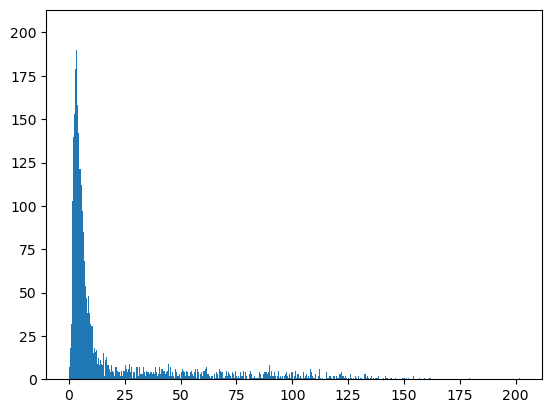

In [21]:
plt.hist(x=np.array(df_snpDens["VARIANTS/KB"]), bins=1000)

In [17]:
array_fn=np.array(df_snpDens["VARIANTS/KB"])
q1 = np.percentile(array_fn, 25)
median_1 = np.percentile(array_fn, 50)
q3 = np.percentile(array_fn, 75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr 

In [18]:
print((df_snpDens["VARIANTS/KB"] > hi).sum())
print((df_snpDens["VARIANTS/KB"] < hi).sum())
print(median_1)
print(hi)
print(len(df_snpDens))

1145
5603
6.0
44.724999999999994
6748


In [ ]:
plt.figure()
plt.boxplot(df_snpDens["VARIANTS/KB"], showfliers=True)
plt.ylabel("QUAL / INFO_DP")
plt.title("QUAL/DP distribution (outliers shown)")
plt.tight_layout()